In [1]:
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'MPMs').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import importlib
import equinox as eqx
import jax.numpy as jnp
import jax
import diffrax as dfx
import numpy as np
import matplotlib.pyplot as plt
import cobra

import MPMs.DATA_functions_01 as DF
import MPMs.UTIL_functions_01 as UF
import MPMs.ANA_functions_02 as AF
import MPMs.HELPER_functions_02 as HF
import MPMs.MPM_functions_07 as MF

importlib.reload(UF)
importlib.reload(DF)
importlib.reload(HF)
importlib.reload(AF);

In [2]:
importlib.reload(AF)
importlib.reload(UF)

versions = []
not_found = []
for nr in [144]:
    nr = f"{nr:02.0f}"
    for let in ["A","B","D"]:
        version = f"MPM_{nr}{let}"
        id = "_sc"
        filepath = f"{REPO_ROOT}/prol_model_data/{version}/analysis{id}.pkl"
        if not os.path.isfile(filepath):
            # print(version, "not found")
            not_found.append(version)
        else:
            versions.append(version)
for nr in [3]:
    nr = f"{nr:02.0f}"
    for let in "ACD":
        version = f"SLIM_{nr}{let}"
        id = "_sc"
        filepath = f"{REPO_ROOT}/slim_model_data/{version}/analysis{id}.pkl"
        if not os.path.isfile(filepath):
            # print(version, "not found")
            not_found.append(version)
        else:
            versions.append(version)

print("NOT FOUND:",not_found)
metrics = ["R2","NMAE"]
_ = AF.NEW_compare_versions(versions,
                            # last_model=False,     # bool, default = True
                            # equal_comparison=False, # bool, default = True
                            metrics=metrics,
                            )
METRIC_values, labels = _

NOT FOUND: []
Last Model       : True
Equal Comparison : True
--- R2   ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
                 MPM_144A |   0.6873 |   0.6037 |   0.8544 |   0.7254 |   0.4821 |   0.9981 |   0.5470 |  NO; incomplete (9 processes)
                 MPM_144B |   0.7962 |   0.7526 |   0.8836 |   0.7511 |   0.7541 |   0.9982 |   0.5659 |  NN; incomplete (9 processes)
                 MPM_144D |   0.7266 |   0.6385 |   0.9028 |   0.4950 |   0.7820 |   0.9983 |   0.4049 |  unknown; incomplete (9 processes)
                 SLIM_03A |      inf |   0.9633 |      inf |   0.9827 |   0.9439 |   1.0000 |   0.9266 |  NO; incomplete (9 processes)
                 SLIM_03C |      inf |   0.9595 |      inf |   0.9686 |   0.9504 |   1.0000 |   0.8571 |  NN; incomplete (9 processes)
                 SLIM_03D |      

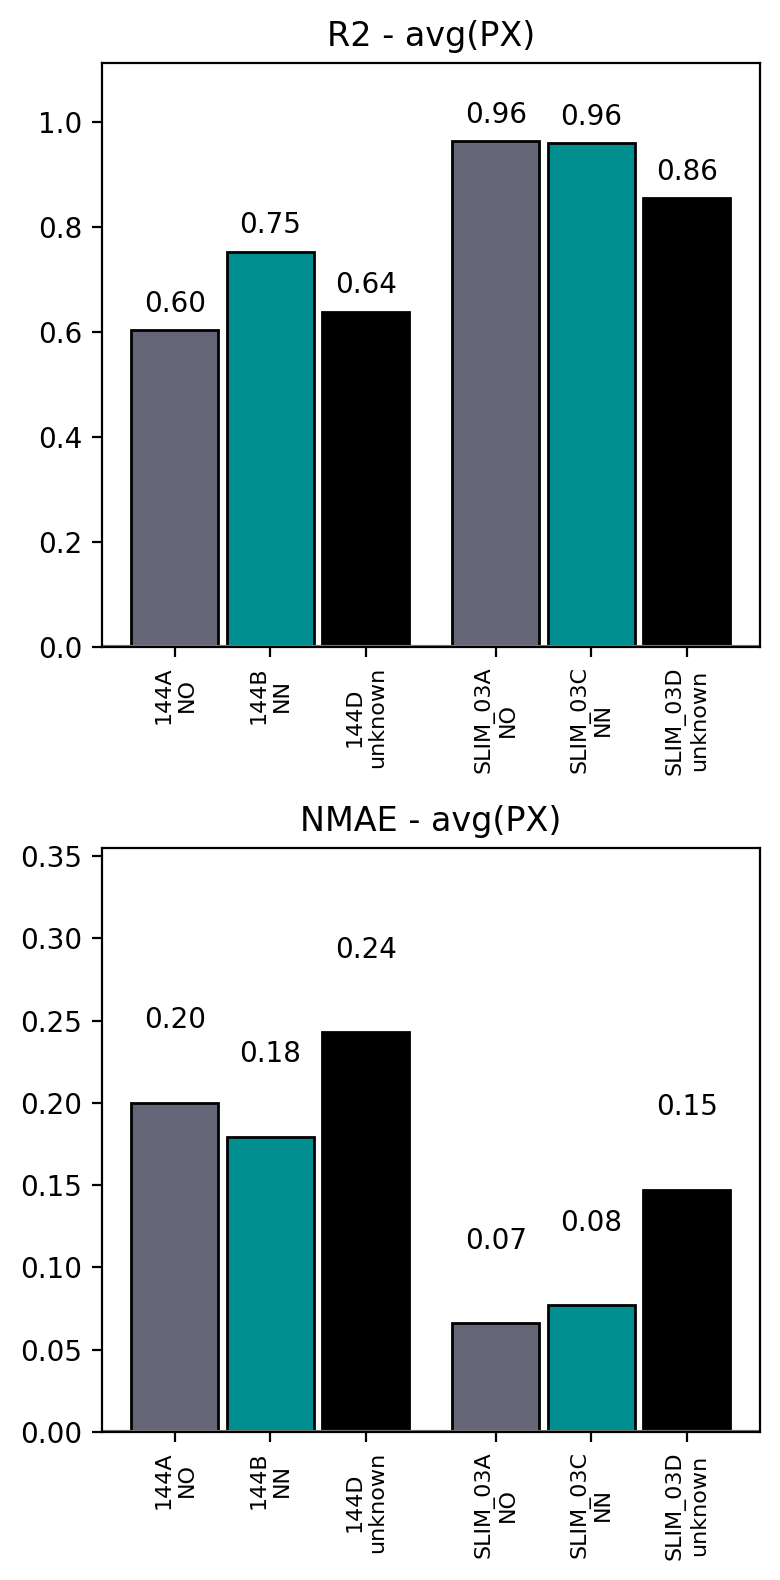

In [3]:
importlib.reload(AF)
METRIC_index = 1
suptitle = labels[METRIC_index]
AF.plot_compare_versions(versions, metrics, METRIC_values, 
                         METRIC_index=METRIC_index, 
                         suptitle=suptitle)

In [4]:
all_combis = np.array(
             [["MPM_141", "ann", "none"],
              ["MPM_142", "ann", "sigmoid"],
              ["MPM_143", "ann", "min"],
              ["MPM_144", "linear", "none"],
              ["MPM_145", "linear", "sigmoid"],
              ["MPM_146", "linear", "min"],])

def get_xticklab(version):
    # print(version[:7])
    i = np.where(all_combis[:,0] == version[:7])[0][0]

    return all_combis[i,1] + "\n" + all_combis[i,2]

def get_ylab(i):
    # metrics[i]
    if metrics[i] == "R2":
        str_1 = r"$R^2$"
    else:
        str_1 = metrics[i]
    if "avg" in suptitle:
        prefix = "mean"
        variables = suptitle.strip("avg()")
        var = ""
        for v in variables:
            var += f"${v}$ and "
        var = var.strip(" and ")
    else:
        prefix = ""
    return f"{prefix} {str_1} of {var}"

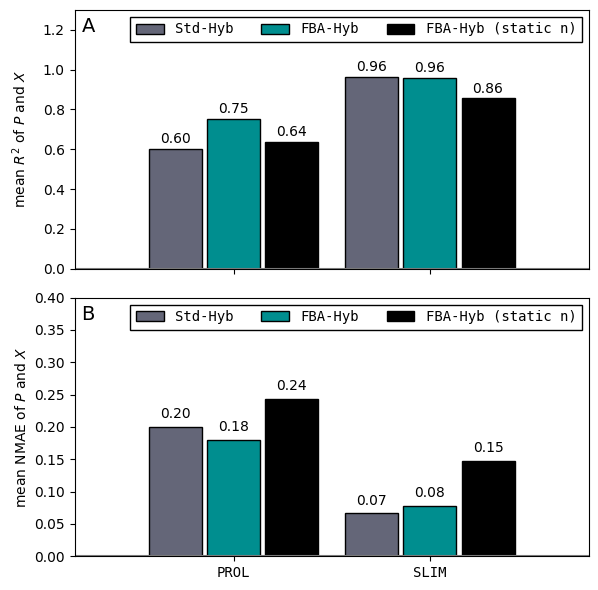

In [5]:
importlib.reload(AF)

fig = plt.figure(dpi=100,figsize=(6,6))
axes = []
for i in range(len(metrics)):
    axes.append(plt.subplot(len(metrics),1,i+1))

    axes[i].set_ylabel(get_ylab(i))

offset = 0
old_version = ""
locs = []
ymax = [1,.4]
laboff = [.05*m for m in ymax]
for i, version in enumerate(versions):
    if old_version != version.split("/")[0][-3:-1]:
        offset += .2
        old_version = version.split("/")[0][-3:-1]

    fba = AF.get_fba_type(version)
    c = AF.get_color_from_fba_type(fba)
    
    loc = i*.55+offset

    for j, metric in enumerate(metrics):
        value = METRIC_values[j][version][METRIC_index]
        text_value = np.max([value+laboff[j]])
        if i in [9,10]:
            hatch = "//"
        else:
            hatch = None
        axes[j].bar( loc,value,color=c,edgecolor="k",width=.5,hatch=hatch)
        axes[j].text(loc,text_value,f"{value:.2f}",va="center",ha="center")
    locs.append(loc)

# legend
for i, ax in enumerate(axes):
    ylim = ax.get_ylim()
    ax.set_ylim(0,ymax[i])
    ax.axhline(0,color="grey")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NO"),edgecolor="k",label="Std-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NN"),edgecolor="k",label="FBA-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("bla"),edgecolor="k",label="FBA-Hyb (static n)")
    # ax.bar(5,-10,color="w",edgecolor="k",hatch="//",label="Final Choice")

    legend = ax.legend(ncols=4)
    for text in legend.get_texts():
        text.set_fontfamily('monospace')

# panel letters
import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],axes):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

axes[0].set_ylim(0,1.3)
axes[1].set_ylim(0,.4)
# axes[0].set_xticks(np.array(locs)[1::3],["" for v in versions[::3]])
# axes[1].set_xticks(np.array(locs)[1::3],[get_xticklab(v) for v in versions[::3]])
# Apply monospace font to the tick labels
axes[0].set_xticks([.75,2.6],[])
axes[1].set_xticks([.75,2.6],["PROL", "SLIM"])
delta = .75+.3225
delta = 1.5
axes[0].set_xlim(.75-delta,2.6+delta)
axes[1].set_xlim(.75-delta,2.6+delta)
for label in axes[1].get_xticklabels():
    label.set_fontfamily('monospace')
fig.align_ylabels()

plt.tight_layout()
plt.show()

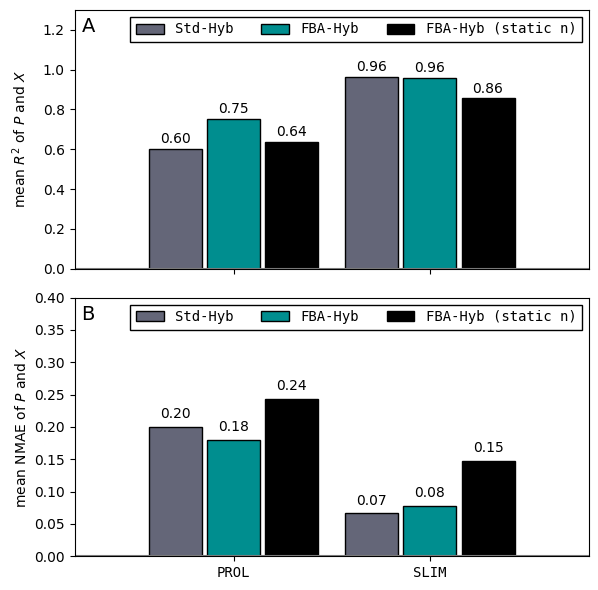

In [6]:
importlib.reload(AF)

fig = plt.figure(dpi=100,figsize=(6,6))
axes = []
for i in range(len(metrics)):
    axes.append(plt.subplot(len(metrics),1,i+1))

    axes[i].set_ylabel(get_ylab(i))

offset = 0
old_version = ""
locs = []
ymax = [1,.4]
laboff = [.05*m for m in ymax]
for i, version in enumerate(versions):
    if old_version != version.split("/")[0][-3:-1]:
        offset += .2
        old_version = version.split("/")[0][-3:-1]

    fba = AF.get_fba_type(version)
    c = AF.get_color_from_fba_type(fba)
    
    loc = i*.55+offset

    for j, metric in enumerate(metrics):
        value = METRIC_values[j][version][METRIC_index]
        text_value = np.max([value+laboff[j]])
        if i in [9,10]:
            hatch = "//"
        else:
            hatch = None
        axes[j].bar( loc,value,color=c,edgecolor="k",width=.5,hatch=hatch)
        axes[j].text(loc,text_value,f"{value:.2f}",va="center",ha="center")
    locs.append(loc)

# legend
for i, ax in enumerate(axes):
    ylim = ax.get_ylim()
    ax.set_ylim(0,ymax[i])
    ax.axhline(0,color="grey")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NO"),edgecolor="k",label="Std-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NN"),edgecolor="k",label="FBA-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("bla"),edgecolor="k",label="FBA-Hyb (static n)")
    # ax.bar(5,-10,color="w",edgecolor="k",hatch="//",label="Final Choice")

    legend = ax.legend(ncols=4)
    for text in legend.get_texts():
        text.set_fontfamily('monospace')

# panel letters
import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],axes):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

axes[0].set_ylim(0,1.3)
axes[1].set_ylim(0,.4)
# axes[0].set_xticks(np.array(locs)[1::3],["" for v in versions[::3]])
# axes[1].set_xticks(np.array(locs)[1::3],[get_xticklab(v) for v in versions[::3]])
# Apply monospace font to the tick labels
axes[0].set_xticks([.75,2.6],[])
axes[1].set_xticks([.75,2.6],["PROL", "SLIM"])
delta = .75+.3225
delta = 1.5
axes[0].set_xlim(.75-delta,2.6+delta)
axes[1].set_xlim(.75-delta,2.6+delta)
for label in axes[1].get_xticklabels():
    label.set_fontfamily('monospace')
fig.align_ylabels()

plt.tight_layout()
plt.show()